# ERK Pathway — Visualisation

Loads the simplified ERK pathway definition (`erk.yaml`) and visualises:
- The DAG structure (nodes = genes, edges = activates/inhibits)
- Derived roles: **activator** (GOF drives pathway) vs **inhibitor** (LOF drives pathway)
- Node size proportional to mutation prevalence in melanoma

Reference: [KEGG hsa04010](https://www.kegg.jp/pathway/hsa04010)

In [1]:
import sys
sys.path.insert(0, "..")

from collections import defaultdict
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx

from evoseer.plugins.pathway import PathwayDefinition, derive_roles

In [2]:
yaml_path = Path("../evoseer/plugins/pathway/data/erk.yaml")
defn = PathwayDefinition.load(yaml_path)

print(f"Pathway : {defn.name}  ({defn.kegg_id})")
print(f"Output  : {defn.output_node}")
print(f"Nodes   : {list(defn.nodes.keys())}")
print(f"Edges   : {len(defn.edges)}")

Pathway : ERK  (hsa04010)
Output  : MAPK1
Nodes   : ['EGFR', 'KRAS', 'NRAS', 'NF1', 'BRAF', 'MAP2K1', 'MAPK1']
Edges   : 8


## Derived roles (parity algorithm)

For each node, count the number of `inhibits` edges on the path to `output_node`:
- **even parity** → activator (GOF mutation activates pathway)
- **odd parity** → inhibitor (LOF mutation activates pathway via disinhibition)

In [3]:
act, inh = derive_roles(defn)

print(f"{'Gene':<12} {'Role':<12} {'Weight':>8}")
print("-" * 34)
for name, node in defn.nodes.items():
    if name in act:
        role = "activator"
    elif name in inh:
        role = "inhibitor"
    else:
        role = "unconnected"
    print(f"{name:<12} {role:<12} {node.weight:>8.2f}")

Gene         Role           Weight
----------------------------------
EGFR         activator        0.01
KRAS         activator        0.02
NRAS         activator        0.20
NF1          inhibitor        0.15
BRAF         activator        0.50
MAP2K1       activator        0.02
MAPK1        activator        0.01


## Build NetworkX DiGraph

In [4]:
G = nx.DiGraph()

for name, node in defn.nodes.items():
    G.add_node(name, weight=node.weight, gene_id=node.gene_id)

for edge in defn.edges:
    G.add_edge(edge.from_node, edge.to_node, type=edge.type)

print(f"Nodes: {G.number_of_nodes()}  Edges: {G.number_of_edges()}")
print(f"DAG: {nx.is_directed_acyclic_graph(G)}")

Nodes: 7  Edges: 8
DAG: True


## Hierarchical layout (upstream → downstream)

In [5]:
def hierarchical_pos(G, x_spacing=2.5, y_spacing=1.5):
    """Assign positions layer by layer using topological generations."""
    generations = list(nx.topological_generations(G))
    pos = {}
    for layer_idx, generation in enumerate(generations):
        nodes = sorted(generation)
        for node_idx, node in enumerate(nodes):
            x = (node_idx - (len(nodes) - 1) / 2) * x_spacing
            y = -layer_idx * y_spacing
            pos[node] = (x, y)
    return pos

pos = hierarchical_pos(G)

## Visualisation

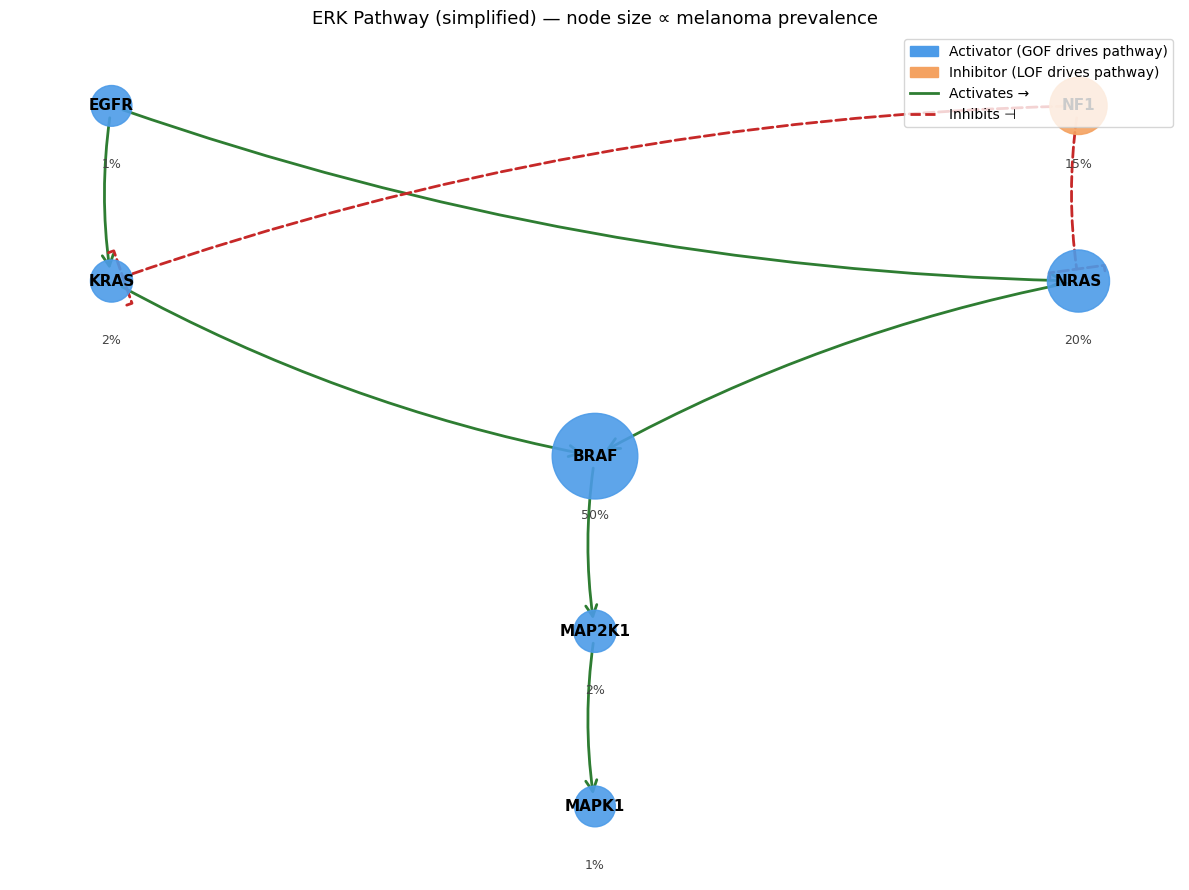

In [6]:
ACTIVATOR_COLOR = "#4C9BE8"   # blue
INHIBITOR_COLOR = "#F4A261"   # orange
UNCONNECTED_COLOR = "#AAAAAA" # gray
ACTIVATES_COLOR = "#2E7D32"   # dark green
INHIBITS_COLOR = "#C62828"    # dark red

node_colors = []
node_sizes = []
for node in G.nodes():
    w = G.nodes[node]["weight"]
    node_sizes.append(w * 6000 + 800)
    if node in act:
        node_colors.append(ACTIVATOR_COLOR)
    elif node in inh:
        node_colors.append(INHIBITOR_COLOR)
    else:
        node_colors.append(UNCONNECTED_COLOR)

activates_edges = [(u, v) for u, v, d in G.edges(data=True) if d["type"] == "activates"]
inhibits_edges  = [(u, v) for u, v, d in G.edges(data=True) if d["type"] == "inhibits"]

fig, ax = plt.subplots(figsize=(12, 9))

nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=11, font_weight="bold")

nx.draw_networkx_edges(
    G, pos, ax=ax, edgelist=activates_edges,
    edge_color=ACTIVATES_COLOR, arrows=True,
    arrowstyle="->", arrowsize=20, width=2,
    connectionstyle="arc3,rad=0.08",
)
nx.draw_networkx_edges(
    G, pos, ax=ax, edgelist=inhibits_edges,
    edge_color=INHIBITS_COLOR, arrows=True,
    arrowstyle="-[", arrowsize=20, width=2, style="dashed",
    connectionstyle="arc3,rad=0.08",
)

# Weight annotations
for node in G.nodes():
    x, y = pos[node]
    w = G.nodes[node]["weight"]
    ax.text(x, y - 0.45, f"{w:.0%}", ha="center", va="top", fontsize=9, color="#444444")

legend_elements = [
    mpatches.Patch(color=ACTIVATOR_COLOR, label="Activator (GOF drives pathway)"),
    mpatches.Patch(color=INHIBITOR_COLOR, label="Inhibitor (LOF drives pathway)"),
    plt.Line2D([0], [0], color=ACTIVATES_COLOR, linewidth=2, label="Activates →"),
    plt.Line2D([0], [0], color=INHIBITS_COLOR,  linewidth=2, linestyle="--", label="Inhibits ⊣"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=10)
ax.set_title("ERK Pathway (simplified) — node size ∝ melanoma prevalence", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()